# Laboratório 1: GANs (dados 2D)

# Tarefa (em duplas)



**Treinar uma GAN com o conjunto *Two Moons* do scikit-learn**

Utilize o código acima como base e adapte-o para o seguinte problema:

1. Gere o conjunto de dados *Two Moons* utilizando a função `make_moons` do [`scikit-learn`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html):

```python
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=4096, noise=0.1, random_state=42)
```

Obs.: lembre-se de normalizar os dados.

2. Substitua os dados de treinamento originais do código pelo conjunto *Two Moons*.  
3. Treine uma GAN (com gerador e discriminador definidos no código) para aprender a distribuição do *Two Moons* (se necessário faça mudanças nas arquiteturas das redes neurais). **Não utilize parada antecipada: treine a GAN por 1000 épocas.**
4. Registre a evolução das perdas do gerador e do discriminador ao longo do treinamento.  
5. Gere gráficos comparando os dados reais (*Two Moons*) e as amostras criadas pelo gerador em diferentes épocas.  
6. Salve o modelo treinado e mostre como carregar e gerar novas amostras a partir dele.  

**Entregáveis:**

Os entregáveis são **cumulativos ao longo da Unidade 1**. Ao final da unidade,
você entregará **apenas dois arquivos**, reunindo todos os laboratórios:

1. **Notebook** (`.ipynb`) — um único notebook com o código de todos os
   laboratórios da unidade, cada um em sua própria seção, na ordem em que foram
   realizados.

   O notebook deve **executar do início ao fim sem erros**, em um kernel novo,
   com *Restart & Run All*. Antes de entregar, execute-o dessa forma e confirme
   que todas as células rodam na ordem em que aparecem e que as saídas exibidas
   correspondem a essa execução. Notebooks que não executarem por completo serão
   penalizados.

2. **Relatório** (`.pdf`) — um único PDF, também organizado em seções, uma por
   laboratório.

Este laboratório corresponde à **Seção 1 — GANs**, que deve conter:

- **Setup**: dados utilizados (parâmetros de `make_moons` e normalização
  aplicada), arquiteturas do gerador e do discriminador, e hiperparâmetros
  (função de perda, otimizador, taxa de aprendizado, tamanho do lote, dimensão
  do vetor de ruído e número de épocas). Se alguma arquitetura ou hiperparâmetro
  do código base for alterado, registre a alteração explicitamente e justifique.
- **Resultados**:
  - curvas de perda do gerador e do discriminador ao longo das épocas;
  - gráficos comparando os dados reais e as amostras geradas em diferentes
    épocas do treinamento, incluindo o início, o meio e o final;
  - amostras geradas pelo modelo salvo e recarregado.
- **Análise**: texto breve (3-6 linhas) discutindo, a partir da inspeção visual
  das figuras, em que medida o gerador reproduziu a distribuição dos dados
  reais, e o que o comportamento das curvas de perda sugere sobre o
  treinamento.

Nos próximos laboratórios da unidade, acrescente uma nova seção a cada arquivo,
preservando as anteriores.

O relatório **não** deve conter código.

A entrega é **única por grupo**. Identifique os integrantes no início do
notebook e na primeira página do relatório.

# Importações

In [26]:
!pip install torchinfo
!pip install torch
!pip install torchvision
!pip install matplotlib
!pip install scikit-learn

In [27]:
import torch                                # Importa a biblioteca principal do PyTorch, usada para computação com tensores
from torch import nn                        # Importa o módulo 'nn' do PyTorch, utilizado para criar e treinar redes neurais
from torch.utils.data import DataLoader     # Importa o DataLoader do PyTorch, que facilita o carregamento de dados em mini-lotes (batches).
from torchvision.transforms import ToTensor # Importa a transformação ToTensor, que converte imagens PIL ou NumPy arrays em tensores PyTorch
from torchinfo import summary               # Importa a função summary da biblioteca torchinfo, usada para exibir a arquitetura do modelo
import matplotlib.pyplot as plt             # Importa o módulo de visualização matplotlib para gerar gráficos.
import os                                   # Importa o módulo padrão do Python para interagir com o sistema operacional (ex.: criar pastas, manipular caminhos de arquivos).

from sklearn import datasets                     # Importa o módulo de conjuntos de dados do sklearn
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler # Para facilitar a normalização dos dados


In [28]:
# Para figuras geradas pelo matplotlib serem exibidas diretamente no notebook
%matplotlib inline

# Define o dispositivo de hardware para execução: usa acelerador (GPU/TPU) se disponível; caso contrário, usa a CPU
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Usando o dispositivo: {device}") # Exibe qual dispositivo está sendo utilizado

# Fixa a semente para ser usada em todos os geradores de números aleatórios.
SEED = 42

torch.manual_seed(SEED)       # Fixa a semente dos geradores aleatórios do PyTorch.


Usando o dispositivo: mps


# Etapas Envolvidas no Treinamento de GANs


# 1. Preparando os Dados de Treinamento

## 1.1 Geração do conjunto de dados two moons

In [29]:
X, y = make_moons(n_samples=4096, noise=0.1, random_state=SEED)

In [30]:
# Normalização dos dados
scaler = StandardScaler()
X = scaler.fit_transform(X)

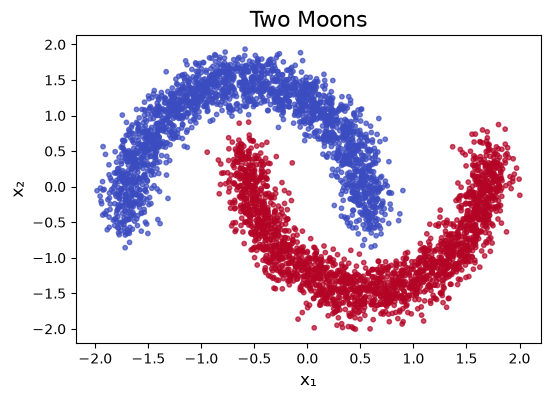

In [31]:
# Visualização do conjunto de dados two moons
plt.figure(dpi=100, figsize=(6, 4))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="coolwarm",
    s=10,
    alpha=0.7
)

plt.xlabel("x₁", fontsize=12)
plt.ylabel("x₂", fontsize=12)
plt.title("Two Moons", fontsize=16)

plt.show()

## 1.2. Preparando o Conjunto de Treinamento

In [32]:
X_tensor = torch.tensor(X, dtype=torch.float32)

batch_size = 128                                 # Define o tamanho de cada mini-lote (quantidade de amostras processadas por iteração).
train_loader = DataLoader(                       # Cria o objeto DataLoader para organizar os dados de treinamento.
    X_tensor,                                    # Conjunto de dados a ser usado (nosso tensor com pares (x, y)).
    batch_size = batch_size,                     # Número de amostras por lote = 128.
    shuffle = True)                              # Embaralha os dados a cada época.

In [33]:
batch0 = next(iter(train_loader))                # Cria um iterador sobre o DataLoader e obtém o primeiro mini-lote de dados (128 amostras).

In [34]:
print(batch0)                                    # Exibe no console o conteúdo desse mini-lote (tensor com shape [128, 2]).

tensor([[ 1.6402e+00, -4.7691e-02],
        [ 1.4758e+00, -4.6334e-01],
        [ 6.7703e-01, -5.5209e-01],
        [ 3.5627e-02,  9.1386e-01],
        [ 5.1232e-01, -1.6547e+00],
        [-3.4259e-01,  1.3660e+00],
        [-1.9849e-01,  1.4387e+00],
        [-1.0262e+00,  1.2004e+00],
        [ 2.0140e-01,  7.6068e-01],
        [-9.7966e-02, -8.6374e-01],
        [ 1.0545e+00, -1.2035e+00],
        [-1.2747e+00,  1.2577e+00],
        [-6.7358e-01, -6.0814e-01],
        [ 6.3673e-01, -1.4291e+00],
        [ 6.0155e-01, -8.4931e-01],
        [-6.4171e-01,  5.4994e-01],
        [ 6.3988e-01, -2.3225e-02],
        [ 6.5109e-01, -1.6673e+00],
        [-1.4106e+00,  7.6331e-01],
        [ 1.3282e+00, -9.8240e-01],
        [-2.7618e-01, -8.1050e-01],
        [ 1.6255e+00, -1.1320e+00],
        [-1.0745e+00,  1.2616e+00],
        [ 4.4009e-01,  1.0053e+00],
        [ 1.6093e+00,  2.7993e-01],
        [-1.4941e+00, -2.5363e-01],
        [-1.6792e+00, -1.7415e-01],
        [-2.1824e-02,  1.209

In [35]:
print(batch0.shape)                              # Exibe no console o tamnho desse mini-lote (tensor com shape [128, 2]).

torch.Size([128, 2])


# 2. Criando Redes Adversárias Generativas (GANs)

## 2.1 Discriminador

In [36]:
import torch.nn as nn        # Importa o módulo nn, que contém blocos para construir redes neurais.

D = nn.Sequential(           # Define o discriminador como uma rede sequencial (camadas empilhadas).
    nn.Linear(2, 256),       # Camada totalmente conectada: entrada com 2 features (x,y); saída com 256 neurônios.
    nn.ReLU(),               # Função de ativação ReLU.
    nn.Dropout(0.3),         # Dropout: desativa aleatoriamente 30% dos neurônios durante o treinamento.
    nn.Linear(256, 128),     # Camada linear: reduz de 256 para 128 neurônios.
    nn.ReLU(),               # Ativação ReLU.
    nn.Dropout(0.3),         # Dropout novamente (30%).
    nn.Linear(128, 64),      # Camada linear: reduz de 128 para 64 neurônios.
    nn.ReLU(),               # Ativação ReLU.
    nn.Dropout(0.3),         # Dropout novamente (30%).
    nn.Linear(64, 1),        # Camada final: reduz de 64 para 1 saída (probabilidade real/fake).
    nn.Sigmoid()             # Função sigmóide: comprime a saída para [0,1], interpretada como probabilidade.
).to(device)                 # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [37]:
print(D)

Sequential(
  (0): Linear(in_features=2, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=64, bias=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=64, out_features=1, bias=True)
  (10): Sigmoid()
)


In [38]:
# Visualização com torchinfo
summary(D, device=device, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 256]                  768
├─ReLU: 1-2                              [1, 256]                  --
├─Dropout: 1-3                           [1, 256]                  --
├─Linear: 1-4                            [1, 128]                  32,896
├─ReLU: 1-5                              [1, 128]                  --
├─Dropout: 1-6                           [1, 128]                  --
├─Linear: 1-7                            [1, 64]                   8,256
├─ReLU: 1-8                              [1, 64]                   --
├─Dropout: 1-9                           [1, 64]                   --
├─Linear: 1-10                           [1, 1]                    65
├─Sigmoid: 1-11                          [1, 1]                    --
Total params: 41,985
Trainable params: 41,985
Non-trainable params: 0
Total m

## 2.2 Gerador

In [39]:
G = nn.Sequential(         # Define o gerador como uma rede neural sequencial (camadas empilhadas).
    nn.Linear(2, 16),      # Primeira camada linear: entrada com 2 dimensões (vetor de ruído); saída com 16 neurônios.
    nn.ReLU(),             # Função de ativação ReLU.
    nn.Linear(16, 32),     # Segunda camada linear: expande de 16 para 32 neurônios.
    nn.ReLU(),             # Função de ativação ReLU.
    nn.Linear(32, 2)       # Camada de saída: gera 2 valores (x, y) que simulam amostras reais.
).to(device)               # Move a rede para o dispositivo escolhido (CPU ou GPU).

In [40]:
print(G)

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=2, bias=True)
)


In [41]:
# Visualização com torchinfo
summary(G, device=device, input_size=(1, 2))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 2]                    --
├─Linear: 1-1                            [1, 16]                   48
├─ReLU: 1-2                              [1, 16]                   --
├─Linear: 1-3                            [1, 32]                   544
├─ReLU: 1-4                              [1, 32]                   --
├─Linear: 1-5                            [1, 2]                    66
Total params: 658
Trainable params: 658
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## 2.3 Hiper-parâmetros

In [42]:
loss_fn = nn.BCELoss()   # Define a função de perda: entropia cruzada binária [Binary Cross-Entropy, BCE]
lr = 0.0002              # Define a taxa de aprendizado [learning rate] para os otimizadores.
βs = (0.5, 0.999)     # Reduz o momentum para 0.5 porque a a distribuição dos dados varia a todo momento, e mantem o momentum quadrático default de 0.999

# Otimizador Adam para o discriminador D: ajusta seus pesos para melhorar a classificação real/falso.
optimD = torch.optim.Adam(
  D.parameters(), 
  betas=βs,
  lr=lr)

# Otimizador Adam para o gerador G: ajusta seus pesos para "enganar" o discriminador.
optimG = torch.optim.Adam(
  G.parameters(), 
  betas=βs,
  lr=lr)

# 3. Treinar e Utilizar GANs para Geração de Formas

## 3.1 Treinar as GANs

In [43]:
# Cria um tensor de rótulos iguais a 1 (amostras reais), tamanho [batch_size, 1] diretamente no device disponivel.
real_labels = torch.ones((batch_size, 1), device=device)

# Cria um tensor de rótulos iguais a 0 (amostras falsas), tamanho [batch_size, 1] diretamente no device disponivel.
fake_labels = torch.zeros((batch_size, 1), device=device)  

In [44]:
def train_D_on_real(real_samples):                  # Função para treinar o discriminador em dados reais.
    real_samples = real_samples.to(device)          # Move o lote de amostras reais para o dispositivo (CPU ou GPU).
    optimD.zero_grad()                              # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(real_samples)                         # Passa as amostras reais pelo discriminador: obtém probabilidades (saída).
    loss_D = loss_fn(out_D, real_labels)            # Calcula a perda comparando saída do discriminador com rótulos = 1 (reais).
    loss_D.backward()                               # Propaga os gradientes da perda para atualizar os pesos.
    optimD.step()                                   # Realiza a atualização dos pesos do discriminador (descida do gradiente).
    return loss_D                                   # Retorna o valor da perda para monitoramento.

In [45]:
def train_D_on_fake():                                # Função para treinar o discriminador em dados falsos (gerados pelo gerador G).
    noise = torch.randn(
        (batch_size, 2), 
        device=device)                                # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2] diretamente no device disponivel.
        
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    optimD.zero_grad()                                # Zera os gradientes acumulados do otimizador do discriminador.
    out_D = D(fake_samples)                           # Passa as amostras falsas pelo discriminador: obtém probabilidades.
    loss_D = loss_fn(out_D, fake_labels)              # Calcula a perda comparando saída do discriminador com rótulos = 0 (falsos).
    loss_D.backward()                                 # Propaga os gradientes da perda para os parâmetros do discriminador.
    optimD.step()                                     # Atualiza os pesos do discriminador com base na perda calculada.
    return loss_D                                     # Retorna a perda para monitoramento.

In [46]:
def train_G():                                        # Função para treinar o gerador (G).
    noise = torch.randn(
        (batch_size, 2), 
        device=device)                                # Gera um lote de vetores de ruído aleatório ~ N(0,1), shape [batch_size, 2] diretamente no device disponivel.
    optimG.zero_grad()                                # Zera os gradientes acumulados do otimizador do gerador.
    fake_samples = G(noise)                           # Passa o ruído pelo gerador: obtém amostras falsas (x, y).
    out_G = D(fake_samples)                           # Passa as amostras falsas no discriminador: obtém probabilidades.
    loss_G = loss_fn(out_G, real_labels)              # Calcula a perda considerando rótulos = 1, POIS O GERADOR QUER QUE O DISCRIMINADOR CLASSIFIQUE AS AMOSTRAS FALSAS COMO REAIS.
    loss_G.backward()                                 # Propaga os gradientes da perda para os parâmetros do gerador.
    optimG.step()                                     # Atualiza os pesos do gerador (descida do gradiente).
    return loss_G, fake_samples                       # Retorna a perda e as amostras falsas geradas para análise/visualização.

In [47]:
def generate_fake_samples(model, num_samples):              # Gera amostras falsas a partir de um modelo.
    with torch.no_grad():                                   # Desabilita o cálculo de gradientes, pois estamos apenas gerando dados.
        noise = torch.randn(
            (num_samples, 2),
            device=device
        )                                                   # Gera vetores de ruído aleatório ~ N(0,1) diretamente no device.
        fake_samples = model(noise)                         # Passa o ruído pelo gerador informado e produz amostras falsas.
        fake = fake_samples.cpu().numpy()                   # Move as amostras geradas para CPU e converte para NumPy.

    return fake                                             # Retorna as amostras geradas em formato NumPy.

In [48]:
# Função reutilizável para comparar visualmente amostras reais e geradas.
def plot_twomoons(real, fake, title, filename):              

    plt.figure(
        dpi=120,
        figsize=(6, 4.5)
    )                                                        # Cria uma figura com boa resolução e tamanho adequado.

    plt.scatter(
        real[:, 0],
        real[:, 1],
        s=6,
        alpha=0.45,
        label="amostras reais"
    )                                                        # Plota as amostras reais como referência visual.

    plt.scatter(
        fake[:, 0],
        fake[:, 1],
        s=6,
        alpha=0.12,
        label="amostras geradas"
    )                                                        # Plota as amostras geradas com maior transparência.

    plt.xlabel("$x_1$")                                      # Define o nome do primeiro eixo.
    plt.ylabel("$x_2$")                                      # Define o nome do segundo eixo.
    plt.title(title)                                         # Define o título recebido como parâmetro.
    plt.axis("equal")                                        # Mantém a mesma escala nos dois eixos para não deformar os dados.
    plt.grid(alpha=0.2)                                      # Adiciona uma grade discreta para facilitar a leitura.
    plt.legend()                                             # Exibe a legenda das amostras reais e geradas.
    plt.tight_layout()                                       # Ajusta automaticamente as margens e espaçamentos.

    plt.savefig(
        filename,
        bbox_inches="tight"
    )                                                        # Salva a figura no arquivo informado.

    plt.show()                                               # Exibe a figura.
    plt.close()                                              # Libera a figura da memória após a exibição.

In [49]:
def test_epoch(epoch, gloss, dloss, n):                      # Função para monitorar e visualizar o progresso do treino.

    if epoch == 0 or (epoch + 1) % 50 == 0:                  # Executa na primeira época e depois a cada 50 épocas.
        num_batches = n + 1                                  # O enumerate começa em zero, portanto o total de lotes é n + 1.
        g = gloss / num_batches                              # Calcula a perda média do gerador por lote.
        d = dloss / num_batches                              # Calcula a perda média do discriminador por lote.

        print(
            f"época {epoch + 1:4d} | "
            f"G loss: {g:.4f} | "
            f"D loss: {d:.4f}"
        )                                       # Exibe as perdas médias da época.

        fake = generate_fake_samples(G, len(X)) # Gera a mesma quantidade de amostras falsas que a quantidade de amostras reais.

        plot_twomoons(
            X,
            fake,
            title=f"Two Moons — época {epoch + 1}",
            filename=f"files/twomoons_p{epoch + 1}.png"
        )                                                    # Gera e salva o gráfico comparando dados reais e dados gerados.

época    1 | G loss: 0.7173 | D loss: 1.3211


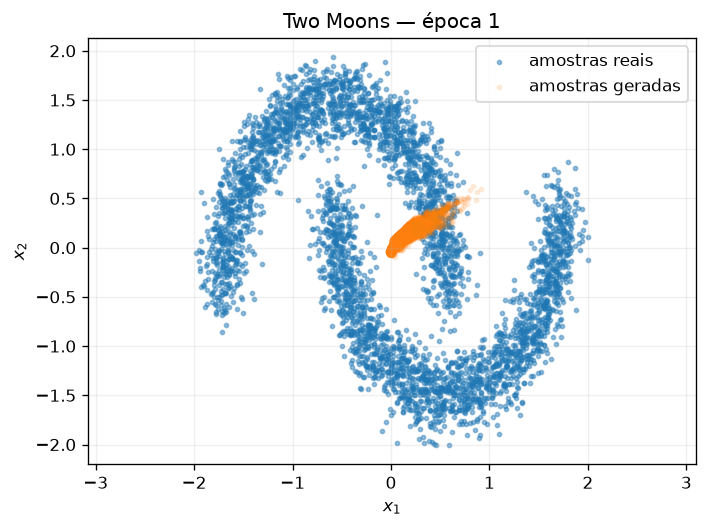

época   50 | G loss: 0.7700 | D loss: 1.3503


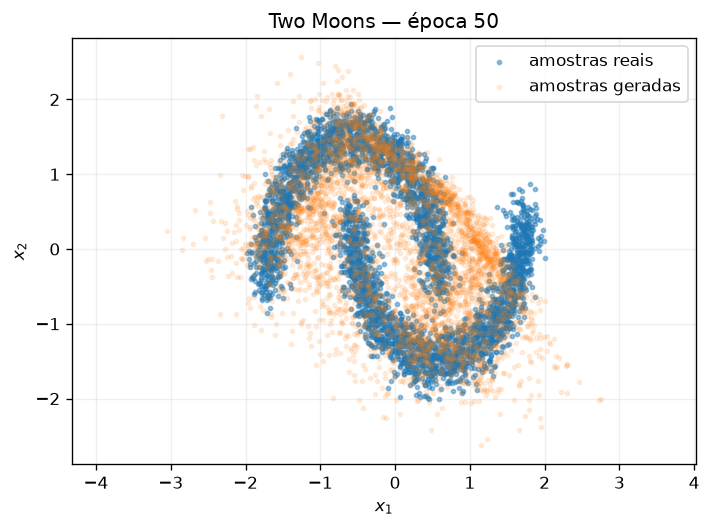

época  100 | G loss: 0.7726 | D loss: 1.3396


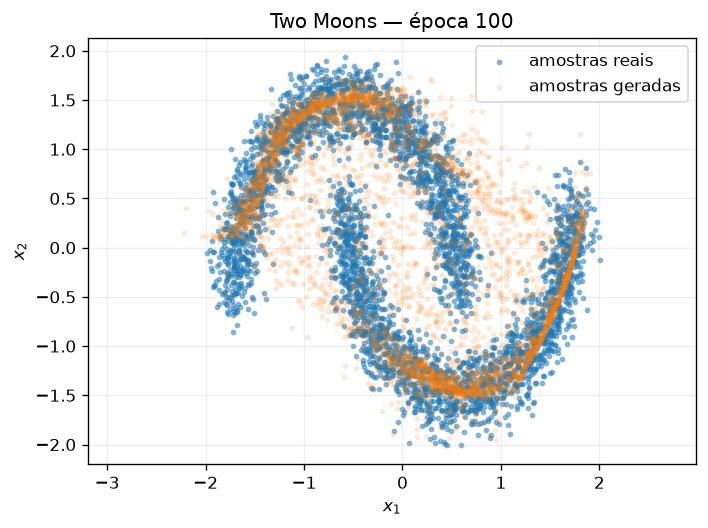

época  150 | G loss: 0.7625 | D loss: 1.3471


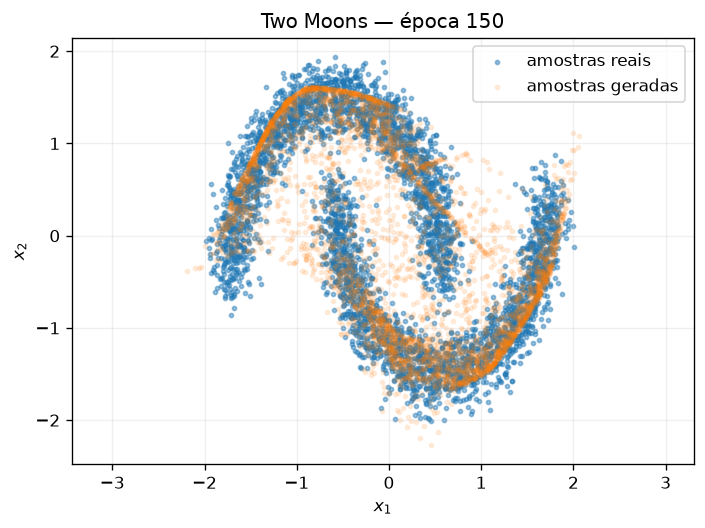

época  200 | G loss: 0.7472 | D loss: 1.3573


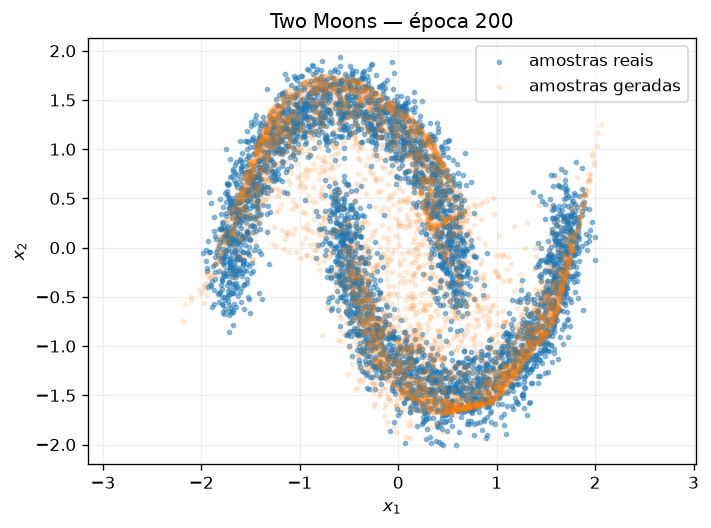

época  250 | G loss: 0.7413 | D loss: 1.3623


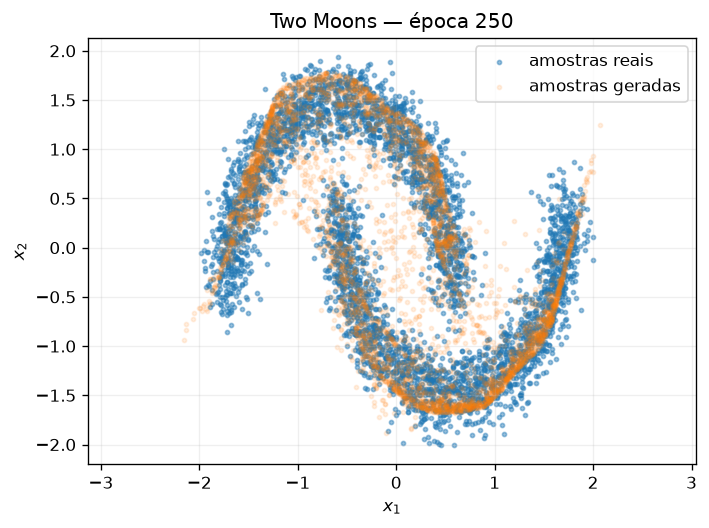

época  300 | G loss: 0.7385 | D loss: 1.3639


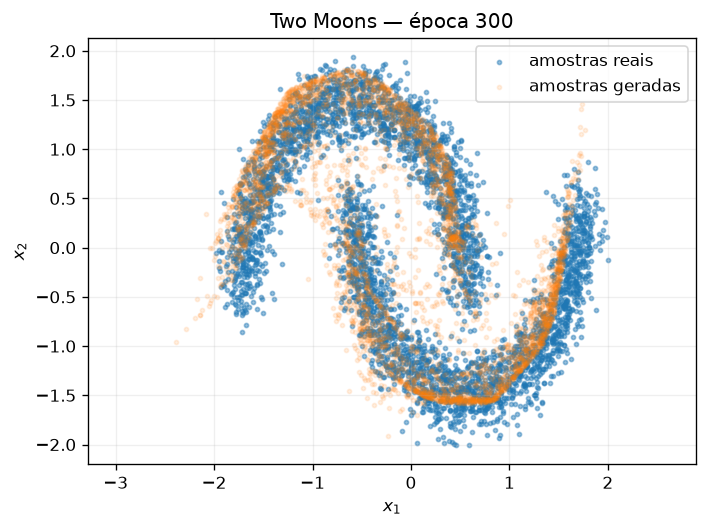

época  350 | G loss: 0.7313 | D loss: 1.3740


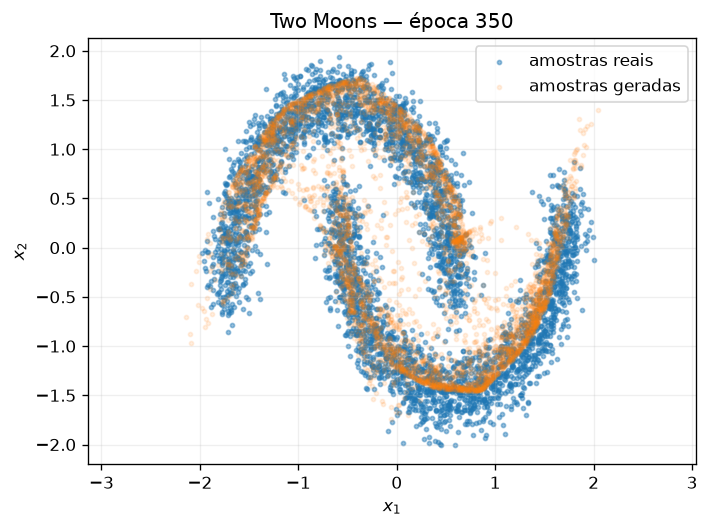

época  400 | G loss: 0.7294 | D loss: 1.3664


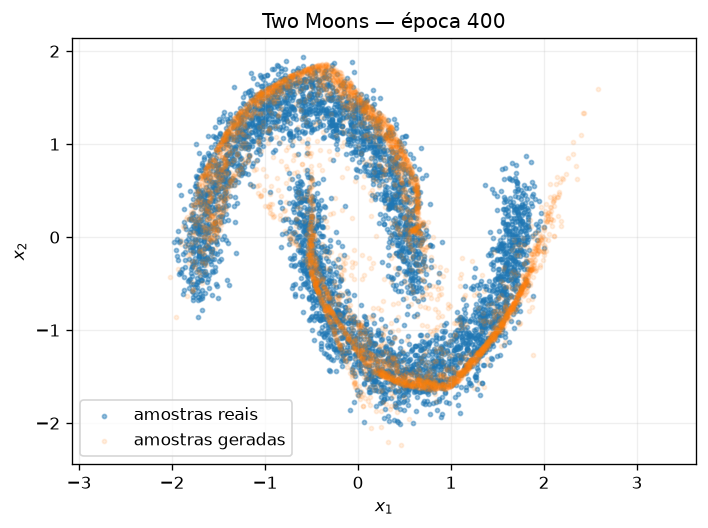

época  450 | G loss: 0.7136 | D loss: 1.3703


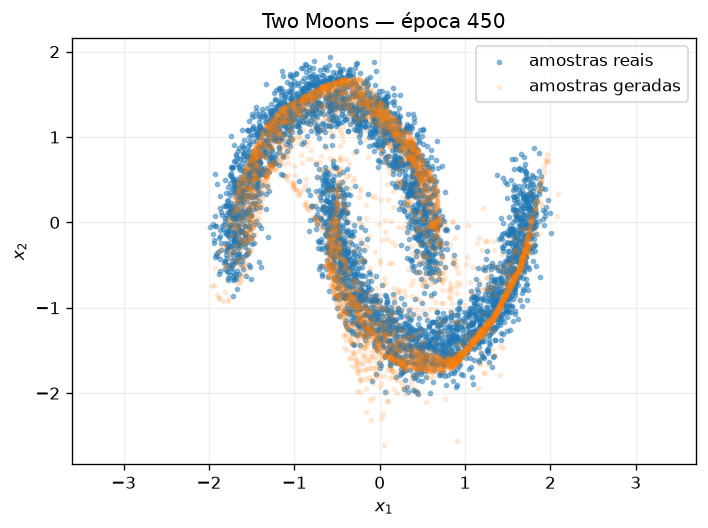

época  500 | G loss: 0.7275 | D loss: 1.3698


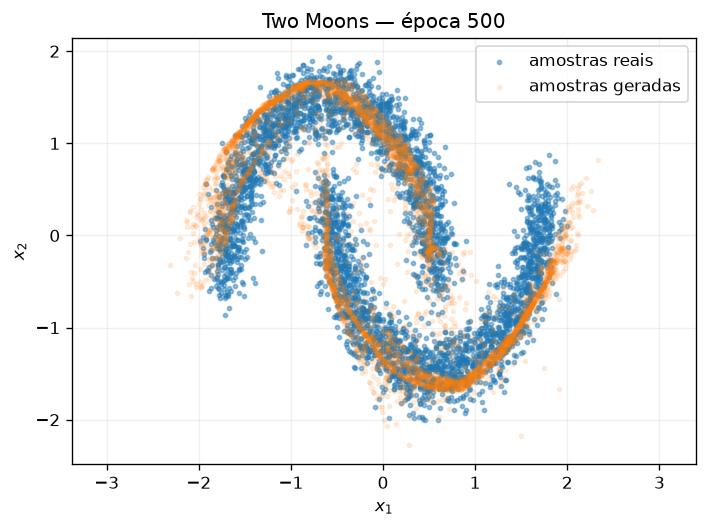

época  550 | G loss: 0.7167 | D loss: 1.3738


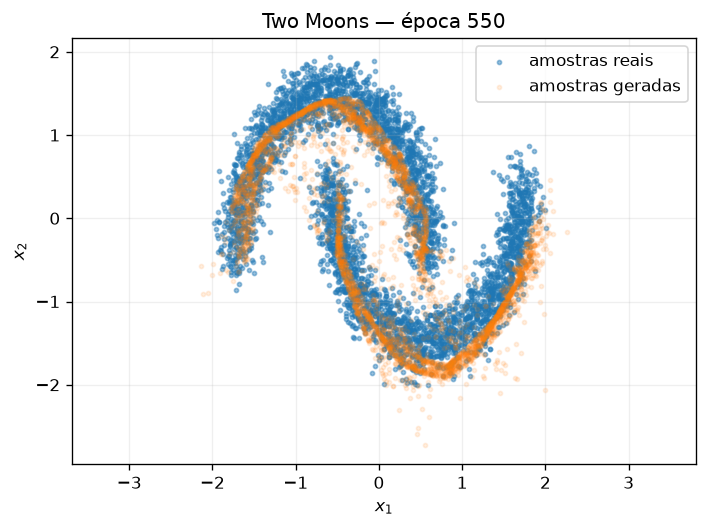

época  600 | G loss: 0.7152 | D loss: 1.3683


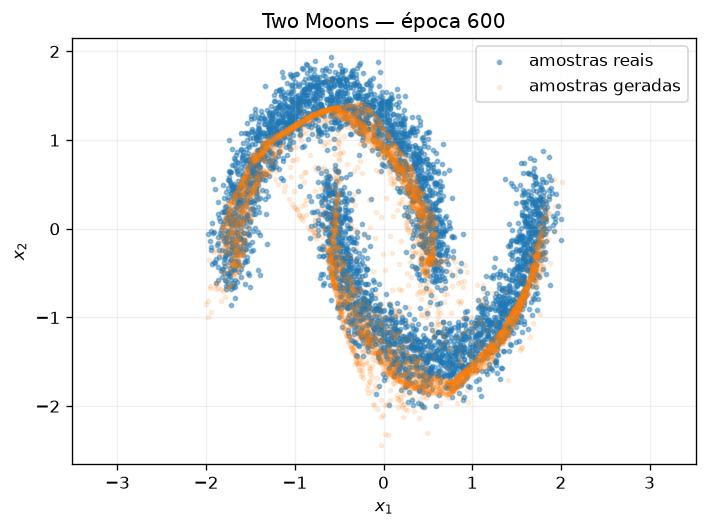

época  650 | G loss: 0.7224 | D loss: 1.3698


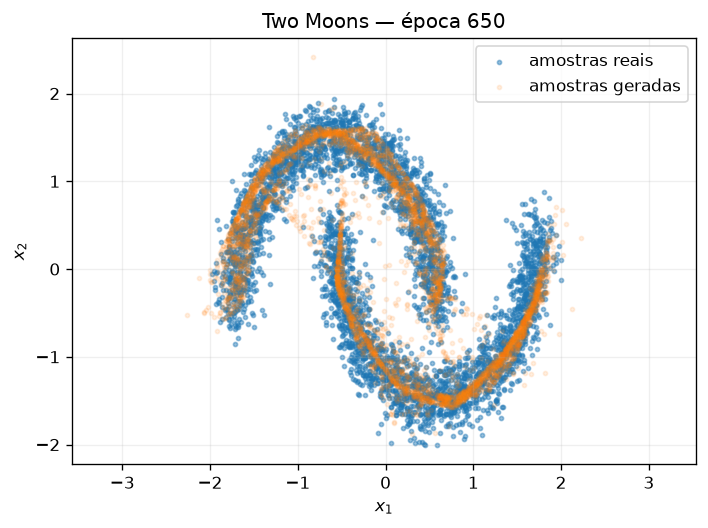

época  700 | G loss: 0.7114 | D loss: 1.3736


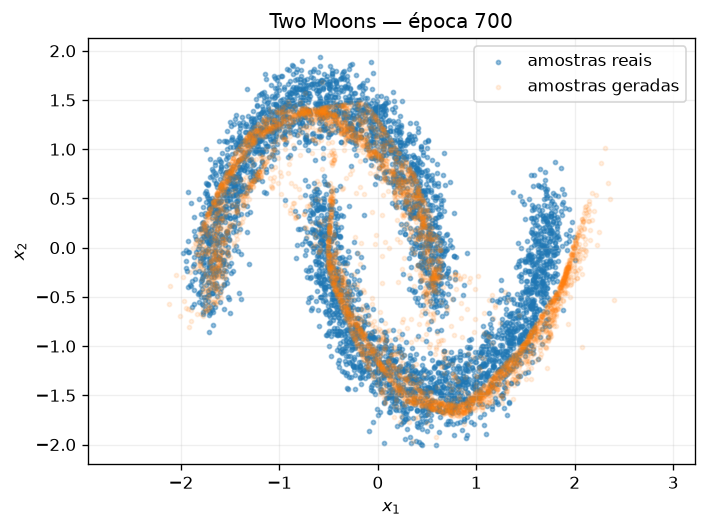

época  750 | G loss: 0.7058 | D loss: 1.3735


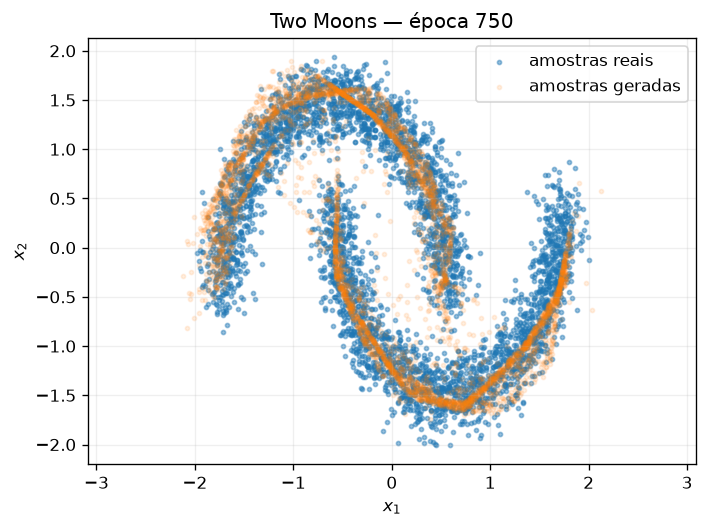

época  800 | G loss: 0.7144 | D loss: 1.3758


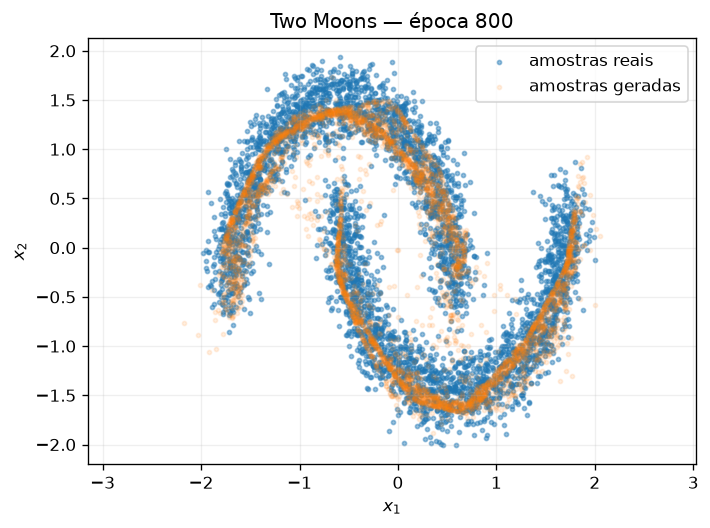

época  850 | G loss: 0.7061 | D loss: 1.3846


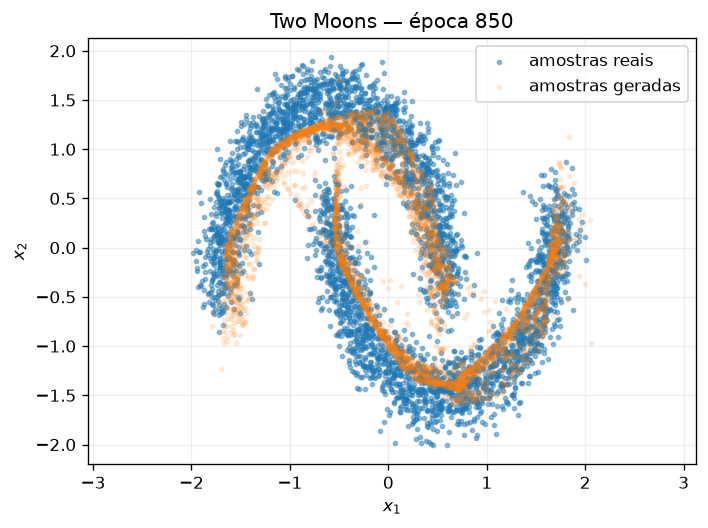

época  900 | G loss: 0.6964 | D loss: 1.3845


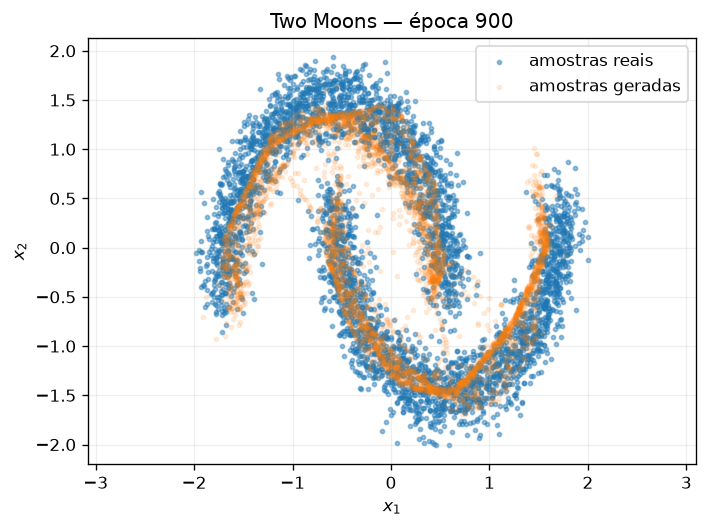

época  950 | G loss: 0.7017 | D loss: 1.3900


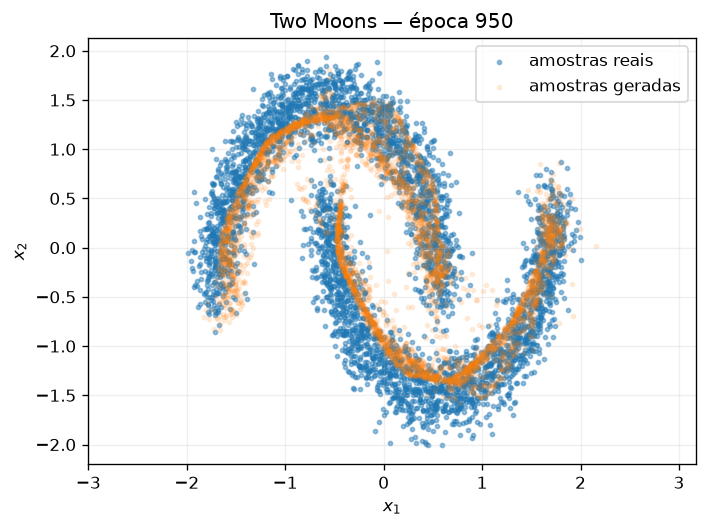

época 1000 | G loss: 0.7079 | D loss: 1.3844


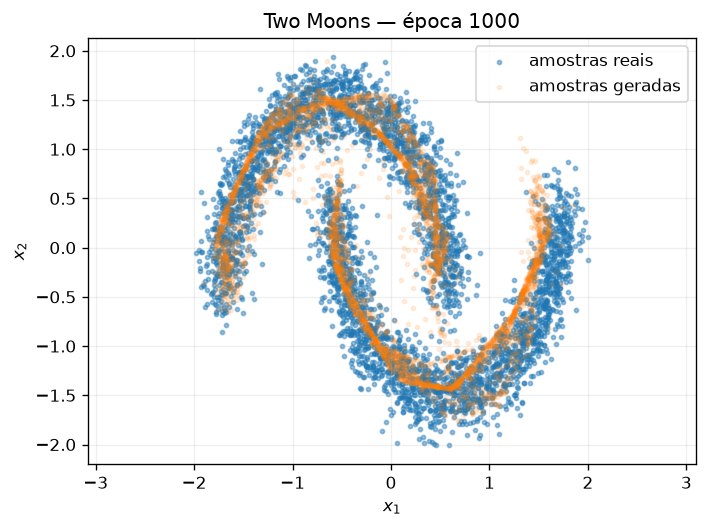

In [50]:
g_loss_history = []                              # Armazena a perda média do gerador em cada época.
d_loss_history = []                              # Armazena a perda média do discriminador em cada época.

for epoch in range(1000):                           # Loop principal de treinamento da GAN por exatamente 1000 épocas.

    gloss = 0.0                                     # Inicializa o acumulador da perda do gerador.
    dloss = 0.0                                     # Inicializa o acumulador da perda do discriminador.

    for n, real_samples in enumerate(train_loader): # Itera sobre os mini-lotes do conjunto de dados reais.

        loss_D = train_D_on_real(real_samples)      # Treina o discriminador usando amostras reais.
        dloss += loss_D.item()                      # Acumula o valor numérico da perda do discriminador para dados reais.
        loss_D = train_D_on_fake()                  # Treina o discriminador usando amostras falsas produzidas pelo gerador.
        dloss += loss_D.item()                      # Acumula o valor numérico da perda do discriminador para dados falsos.
        loss_G, fake_samples = train_G()            # Treina o gerador e obtém as amostras falsas produzidas nessa iteração.
        gloss += loss_G.item()                      # Acumula o valor numérico da perda do gerador.

    g_epoch_loss = gloss / (n + 1) 
    d_epoch_loss = dloss / (n + 1) 
    g_loss_history.append(g_epoch_loss)
    d_loss_history.append(d_epoch_loss)

    test_epoch(
        epoch,
        gloss,
        dloss,
        n
    )                                               # Exibe métricas e plota amostras na primeira época e a cada 25 épocas.

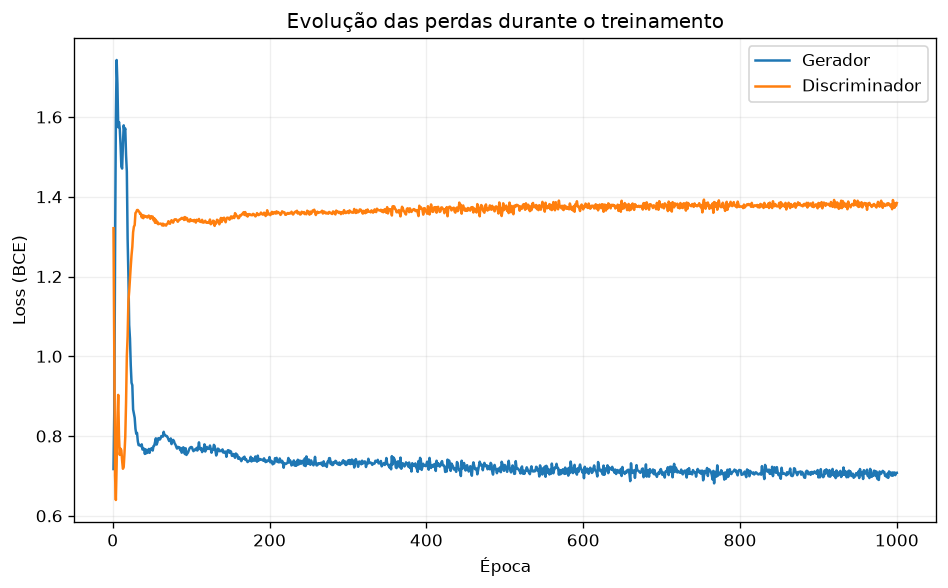

In [51]:
plt.figure(
    dpi=120,
    figsize=(8, 5)
)                                                     # Cria a figura para visualizar a evolução das perdas.


plt.plot(
    range(1, 1001),
    g_loss_history,
    label="Gerador"
)                                                     # Plota a perda média do gerador ao longo das épocas.


plt.plot(
    range(1, 1001),
    d_loss_history,
    label="Discriminador"
)                                                     # Plota a perda média do discriminador ao longo das épocas.


plt.xlabel("Época")                                  # Define o eixo X como o número da época.
plt.ylabel("Loss (BCE)")                             # Define o eixo Y como o valor da Binary Cross-Entropy.
plt.title("Evolução das perdas durante o treinamento")  # Define o título do gráfico.
plt.grid(alpha=0.2)                                  # Adiciona uma grade discreta para facilitar a leitura.
plt.legend()                                         # Exibe a legenda identificando G e D.
plt.tight_layout()                                   # Ajusta automaticamente as margens da figura.

plt.savefig(
    "files/twomoons_loss_history.png",
    bbox_inches="tight"
)                                                     # Salva o gráfico final das perdas.

plt.show()                                           # Exibe o gráfico.

## 3.2 Salvar e utilizar o modelo treinado

In [52]:
scripted = torch.jit.script(G)                       # Converte o gerador (G) para o formato TorchScript.
scripted.save('files/twomoons.pt')                # Salva o modelo convertido no arquivo "exponential.pt" dentro da pasta "files".

In [53]:
new_G = torch.jit.load('files/twomoons.pt',       # Carrega o modelo salvo em TorchScript a partir do arquivo "twomoons.pt".
                       map_location=device)          # Garante que o modelo seja carregado no dispositivo correto (CPU ou GPU).
new_G.eval()                                         # Coloca o modelo no modo de avaliação (desativa dropout, batchnorm em modo treino, etc.).

RecursiveScriptModule(
  original_name=Sequential
  (0): RecursiveScriptModule(original_name=Linear)
  (1): RecursiveScriptModule(original_name=ReLU)
  (2): RecursiveScriptModule(original_name=Linear)
  (3): RecursiveScriptModule(original_name=ReLU)
  (4): RecursiveScriptModule(original_name=Linear)
)

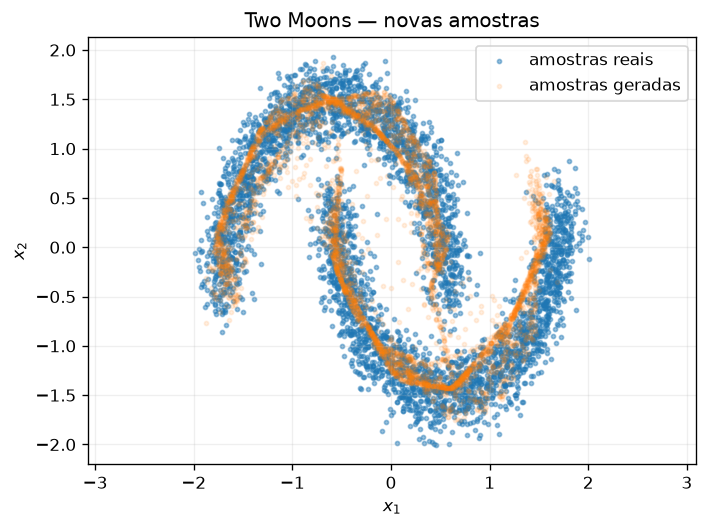

In [54]:
# Gera novas amostras usando o gerador carregado.
new_data = generate_fake_samples(new_G, len(X))             
# Gera o gráfico utilizando a mesma função usada durante o treinamento.
plot_twomoons(
    X,
    new_data,
    title="Two Moons — novas amostras",
    filename="files/twomoons_new_generation.png"
)                                                            